# 01 — Data Collection

Download and inspect MLS match data from Football-Data.co.uk.
This notebook verifies data integrity and explores the raw dataset.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from mls_predictor.data_loader import load_raw_data
from mls_predictor.config import MIN_SEASON, DATA_DIR

In [2]:
df = load_raw_data()
print(f"Dataset: {len(df)} matches from {df['Date'].min()} to {df['Date'].max()}")
print(f"Seasons: {sorted(df['Season'].unique())}")
print(f"Teams: {len(set(df['HomeTeam'].unique()) | set(df['AwayTeam'].unique()))}")
df.head()

Dataset: 2290 matches from 2022-02-26 00:00:00 to 2026-05-25 00:00:00
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Teams: 30


,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Season,PSCH,PSCD,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365CH,B365CD,B365CA
0,2022-02-26,18:00,Philadelphia Union,Minnesota United,1,1,D,2022,2.00,3.38,4.32,2.01,3.56,4.32,1.96,3.36,3.96,NaN,NaN,NaN
1,2022-02-26,20:30,Columbus Crew,Vancouver Whitecaps,4,0,H,2022,1.59,4.07,6.44,1.67,4.35,6.51,1.57,4.02,5.79,NaN,NaN,NaN
2,2022-02-26,20:30,Los Angeles FC,Colorado Rapids,3,0,H,2022,1.71,3.90,5.23,1.85,4.10,5.23,1.74,3.79,4.57,NaN,NaN,NaN
3,2022-02-26,22:30,FC Dallas,Toronto FC,1,1,D,2022,1.98,3.86,3.77,2.18,3.88,4.20,1.97,3.63,3.63,NaN,NaN,NaN
4,2022-02-26,23:00,Austin FC,FC Cincinnati,5,0,H,2022,1.66,4.25,5.22,1.72,4.25,5.50,1.66,3.91,4.95,NaN,NaN,NaN


In [3]:
# Data types and missing values
print(df.dtypes)
print('\n--- Missing Values ---')
missing = df.isnull().sum()
print(missing[missing > 0])

Date        datetime64[us]
Time                   str
HomeTeam               str
AwayTeam               str
FTHG                 int64
FTAG                 int64
FTR                    str
Season               int64
PSCH               float64
PSCD               float64
PSCA               float64
MaxCH              float64
MaxCD              float64
MaxCA              float64
AvgCH                  str
AvgCD              float64
AvgCA              float64
B365CH             float64
B365CD             float64
B365CA             float64
dtype: object

--- Missing Values ---
PSCH       233
PSCD       233
PSCA       233
B365CH    1910
B365CD    1910
B365CA    1910
dtype: int64


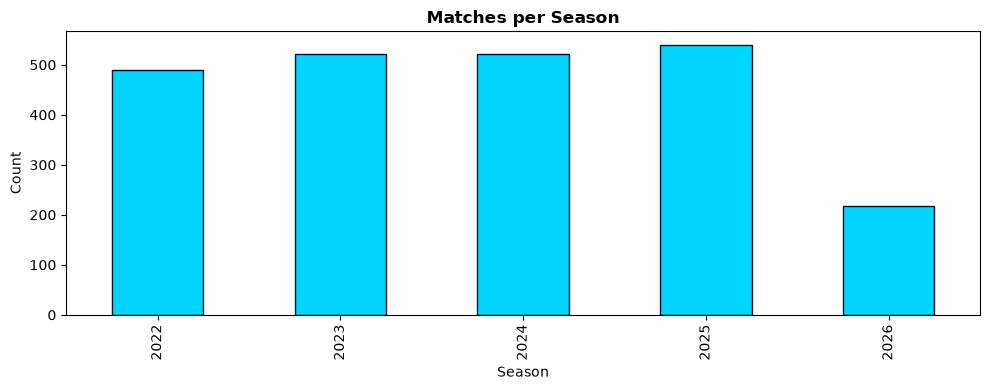

In [4]:
# Matches per season
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby('Season').size().plot(kind='bar', ax=ax, color='#00d4ff', edgecolor='#0a0e1a')
ax.set_title('Matches per Season', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

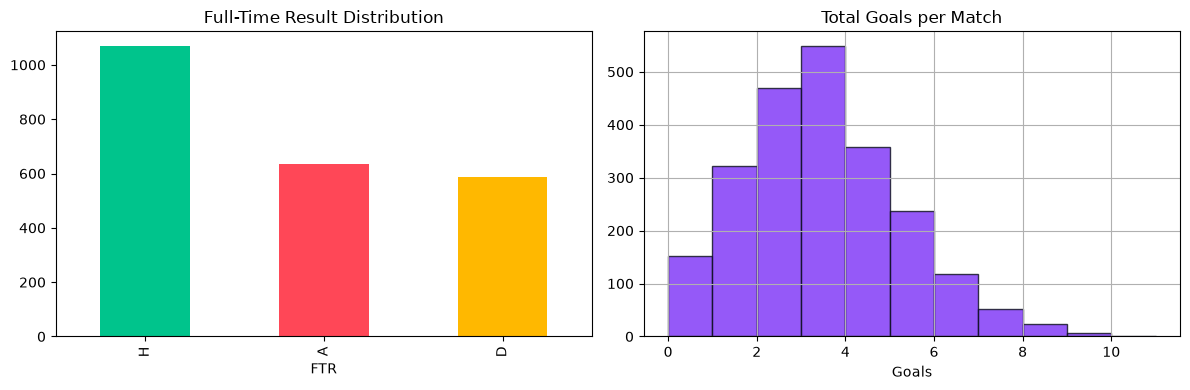


Home Win: 46.7%
Draw:     25.6%
Away Win: 27.7%
Avg Goals/Match: 2.99


In [5]:
# Result distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'H': '#00c48c', 'D': '#ffb800', 'A': '#ff4757'}
df['FTR'].value_counts().plot(kind='bar', ax=axes[0], color=[colors[x] for x in df['FTR'].value_counts().index])
axes[0].set_title('Full-Time Result Distribution')

total_goals = df['FTHG'] + df['FTAG']
total_goals.hist(bins=range(0, 12), ax=axes[1], color='#7b2ff7', edgecolor='#0a0e1a', alpha=0.8)
axes[1].set_title('Total Goals per Match')
axes[1].set_xlabel('Goals')

plt.tight_layout()
plt.show()

print(f"\nHome Win: {(df['FTR']=='H').mean():.1%}")
print(f"Draw:     {(df['FTR']=='D').mean():.1%}")
print(f"Away Win: {(df['FTR']=='A').mean():.1%}")
print(f"Avg Goals/Match: {total_goals.mean():.2f}")

In [6]:
# Odds coverage
odds_cols = ['PSCH', 'PSCD', 'PSCA', 'B365CH', 'B365CD', 'B365CA', 'AvgCH', 'AvgCD', 'AvgCA']
print('Odds coverage per column:')
for col in odds_cols:
    if col in df.columns:
        coverage = df[col].notna().mean()
        print(f'  {col}: {coverage:.1%}')

Odds coverage per column:
  PSCH: 89.8%
  PSCD: 89.8%
  PSCA: 89.8%
  B365CH: 16.6%
  B365CD: 16.6%
  B365CA: 16.6%
  AvgCH: 100.0%
  AvgCD: 100.0%
  AvgCA: 100.0%
